# Лабораторная работа №4 — Классификация ЭЭГ для определения эпилепсии

**Цель:** обучить свёрточную нейронную сеть, которая по короткому фрагменту ЭЭГ
определяет, идёт ли в этот момент эпилептический приступ.





## 1. Установка зависимостей


In [ ]:
# Раскомментировать при первом запуске
# !pip install -q mne pywavelets tensorflow scikit-learn pillow matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Импорт библиотек

In [ ]:
import os
import re
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import mne
mne.set_log_level('ERROR')   

import pywt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print('TensorFlow:', tf.__version__)
print('MNE:', mne.__version__)
print('PyWavelets:', pywt.__version__)


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow: 2.21.0
MNE: 1.12.1
PyWavelets: 1.8.0


## 3. Параметры эксперимента



In [ ]:
DATA_DIR    = Path('data/chb08')      
IMG_DIR     = Path('images')        
SEIZURE_DIR = IMG_DIR / 'seizure'     
NORMAL_DIR  = IMG_DIR / 'normal'     
MODEL_PATH  = Path('eeg_cnn_model.keras')

DATA_DIR.mkdir(parents=True, exist_ok=True)
SEIZURE_DIR.mkdir(parents=True, exist_ok=True)
NORMAL_DIR.mkdir(parents=True, exist_ok=True)

WINDOW_SEC  = 4.0      
N_SEIZURE   = 60       
N_NORMAL    = 60      

WAVELET     = 'morl'   
N_SCALES    = 64       
F_MIN, F_MAX = 1, 50   


IMG_SIZE    = 64      
BATCH_SIZE  = 16
EPOCHS      = 50

BASE_URL    = 'https://physionet.org/files/chbmit/1.0.0/chb08/'
SEIZURE_FILES_TO_DOWNLOAD = ['chb08_02.edf', 'chb08_05.edf', 'chb08_11.edf']


WAVELET     = 'cmor1.5-1.0'   
N_SCALES    = 80              
F_MIN, F_MAX = 1, 60          
LPF_CUTOFF  = 60.0           

print('Конфигурация загружена.')

Конфигурация загружена.


## 4. Скачивание данных из PhysioNet

Скачивание медленное, поэтому проще вручную скачать и закинуть файлы

In [ ]:
def download_if_missing(filename: str, dest_dir: Path = DATA_DIR) -> Path:
    """Скачать файл из PhysioNet, если его нет локально."""
    local_path = dest_dir / filename
    if local_path.exists():
        size_mb = local_path.stat().st_size / (1024 * 1024)
        print(f'  ✓ {filename} уже есть ({size_mb:.1f} МБ)')
        return local_path
    url = BASE_URL + filename
    print(f'  ⬇  Скачиваем {filename} ...', end=' ', flush=True)
    urllib.request.urlretrieve(url, local_path)
    size_mb = local_path.stat().st_size / (1024 * 1024)
    print(f'готово ({size_mb:.1f} МБ)')
    return local_path


download_if_missing('chb08-summary.txt')


print('\nСкачиваем EDF-файлы с приступами...')
for fname in SEIZURE_FILES_TO_DOWNLOAD:
    download_if_missing(fname)

total_mb = sum(p.stat().st_size for p in DATA_DIR.iterdir()) / (1024 * 1024)
print(f'\nИтого на диске: {total_mb:.1f} МБ')

  ✓ chb08-summary.txt уже есть (0.0 МБ)

Скачиваем EDF-файлы с приступами...
  ✓ chb08_02.edf уже есть (40.4 МБ)
  ✓ chb08_05.edf уже есть (40.4 МБ)
  ✓ chb08_11.edf уже есть (40.4 МБ)

Итого на диске: 121.3 МБ


## 5. Разбор summary-файла


In [ ]:
def parse_summary(summary_path: Path) -> dict:
    """Возвращает {имя_файла: [(start_sec, end_sec), ...]}."""
    text = summary_path.read_text()
    seizure_events = {}
    blocks = re.split(r'File Name:\s*', text)
    for block in blocks[1:]:
        first_line = block.split('\n', 1)[0].strip()
        if not first_line.endswith('.edf'):
            continue
        starts = re.findall(r'Seizure(?:\s+\d+)?\s+Start Time:\s*(\d+)\s*seconds', block)
        ends   = re.findall(r'Seizure(?:\s+\d+)?\s+End Time:\s*(\d+)\s*seconds',   block)
        events = list(zip(map(int, starts), map(int, ends)))
        if events:
            seizure_events[first_line] = events
    return seizure_events

events = parse_summary(DATA_DIR / 'chb08-summary.txt')

print(f'Файлов с приступами в chb08: {len(events)}')
print('-' * 50)
for fname, evs in events.items():
    for s, e in evs:
        print(f'  {fname}: приступ с {s}-й по {e}-ю сек ({e-s} с)')

Файлов с приступами в chb08: 5
--------------------------------------------------
  chb08_02.edf: приступ с 2670-й по 2841-ю сек (171 с)
  chb08_05.edf: приступ с 2856-й по 3046-ю сек (190 с)
  chb08_11.edf: приступ с 2988-й по 3122-ю сек (134 с)
  chb08_13.edf: приступ с 2417-й по 2577-ю сек (160 с)
  chb08_21.edf: приступ с 2083-й по 2347-ю сек (264 с)


## 6. Нарезка сигнала на окна


In [ ]:
def extract_segments(edf_path: Path,
                     seizure_intervals: list,
                     window_sec: float = WINDOW_SEC):
    """Усредняет все ЭЭГ-каналы в один сигнал, фильтрует ФНЧ 60 Гц,
    режет на окна. Возвращает (приступы, норма, sfreq)."""
    raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)
    sfreq = raw.info['sfreq']

    raw.filter(l_freq=None, h_freq=LPF_CUTOFF, verbose=False)

    data = raw.get_data()           
    signal = data.mean(axis=0)      

    n_samples = signal.shape[0]
    win = int(window_sec * sfreq)

    is_seizure = np.zeros(n_samples, dtype=bool)
    for s, e in seizure_intervals:
        is_seizure[int(s * sfreq):int(e * sfreq)] = True

    seizure_segs, normal_segs = [], []
    for i in range(0, n_samples - win + 1, win):
        seg = signal[i:i + win]
        frac = is_seizure[i:i + win].mean()
        if frac == 1.0:
            seizure_segs.append(seg)
        elif frac == 0.0:
            normal_segs.append(seg)
    return seizure_segs, normal_segs, sfreq

all_seizure, all_normal = [], []
sfreq_global = None
for fname in SEIZURE_FILES_TO_DOWNLOAD:
    print(f'Обрабатываем {fname}...')
    sez, norm, sfreq_global = extract_segments(DATA_DIR / fname, events[fname])
    print(f'    окон с приступом: {len(sez)}, без приступа: {len(norm)}')
    all_seizure.extend(sez)
    all_normal.extend(norm)

print(f'\nЧастота дискретизации: {sfreq_global} Гц')
print(f'Всего окон с приступом: {len(all_seizure)}')
print(f'Всего окон без приступа: {len(all_normal)}')

Обрабатываем chb08_02.edf...


C:\Users\Егор Букин\AppData\Local\Temp\ipykernel_6660\3209008939.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)


    окон с приступом: 42, без приступа: 856
Обрабатываем chb08_05.edf...


C:\Users\Егор Букин\AppData\Local\Temp\ipykernel_6660\3209008939.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)


    окон с приступом: 47, без приступа: 852
Обрабатываем chb08_11.edf...


C:\Users\Егор Букин\AppData\Local\Temp\ipykernel_6660\3209008939.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)


    окон с приступом: 33, без приступа: 866

Частота дискретизации: 256.0 Гц
Всего окон с приступом: 122
Всего окон без приступа: 2574


In [ ]:
rng = np.random.default_rng(SEED)


if len(all_seizure) > N_SEIZURE:
    idx = rng.choice(len(all_seizure), size=N_SEIZURE, replace=False)
    all_seizure = [all_seizure[i] for i in idx]

idx = rng.choice(len(all_normal), size=N_NORMAL, replace=False)
all_normal = [all_normal[i] for i in idx]

print(f'После балансировки: приступы = {len(all_seizure)}, норма = {len(all_normal)}')
assert len(all_seizure) >= 50 and len(all_normal) >= 50, \
       'По заданию нужно минимум 50 окон каждого класса!'

После балансировки: приступы = 60, норма = 60


## 7. Вейвлет-скалограмма как изображение


In [ ]:
def make_scalogram(signal: np.ndarray, sfreq: float) -> np.ndarray:
    """CWT с комплексным Морле; возвращает мощность в дБ."""
    fc     = pywt.central_frequency(WAVELET)
    freqs  = np.logspace(np.log10(F_MIN), np.log10(F_MAX), N_SCALES)
    scales = fc * sfreq / freqs
    coef, _ = pywt.cwt(signal, scales, WAVELET, sampling_period=1.0 / sfreq)
    power  = np.abs(coef) ** 2
    return 10.0 * np.log10(power + 1e-12)   # дБ


_magma = plt.get_cmap('magma')

def estimate_vmin_vmax(segments: list, sfreq: float,
                       q_low: float = 1, q_high: float = 99) -> tuple:
    """1-й и 99-й процентили дБ-мощности по всем сегментам."""
    pool = []
    for seg in segments:
        pool.append(make_scalogram(seg, sfreq).ravel())
    pool = np.concatenate(pool)
    return float(np.percentile(pool, q_low)), float(np.percentile(pool, q_high))


def save_scalogram_png(signal: np.ndarray,
                       sfreq: float,
                       out_path: Path,
                       vmin: float,
                       vmax: float,
                       img_size: int = IMG_SIZE) -> None:
    sg = make_scalogram(signal, sfreq)
    sg = np.clip((sg - vmin) / (vmax - vmin + 1e-9), 0, 1)
    rgb = (_magma(sg)[:, :, :3] * 255).astype(np.uint8)
    img = Image.fromarray(rgb).transpose(Image.FLIP_TOP_BOTTOM)
    img = img.resize((img_size, img_size), Image.BILINEAR)
    img.save(out_path)



VMIN, VMAX = estimate_vmin_vmax(all_seizure + all_normal, sfreq_global)
print(f'Глобальный диапазон дБ: VMIN={VMIN:.1f}, VMAX={VMAX:.1f}')

print('Создаём изображения класса "приступ"...')
for i, seg in enumerate(all_seizure):
    save_scalogram_png(seg, sfreq_global, SEIZURE_DIR / f'sz_{i:03d}.png',
                       vmin=VMIN, vmax=VMAX)
print(f'  ✓ {len(all_seizure)} файлов в {SEIZURE_DIR}')

print('Создаём изображения класса "норма"...')
for i, seg in enumerate(all_normal):
    save_scalogram_png(seg, sfreq_global, NORMAL_DIR / f'nm_{i:03d}.png',
                       vmin=VMIN, vmax=VMAX)
print(f'  ✓ {len(all_normal)} файлов в {NORMAL_DIR}')

Глобальный диапазон дБ: VMIN=-119.8, VMAX=-72.3
Создаём изображения класса "приступ"...
  ✓ 60 файлов в images\seizure
Создаём изображения класса "норма"...
  ✓ 60 файлов в images\normal


### 7.1 Примеры


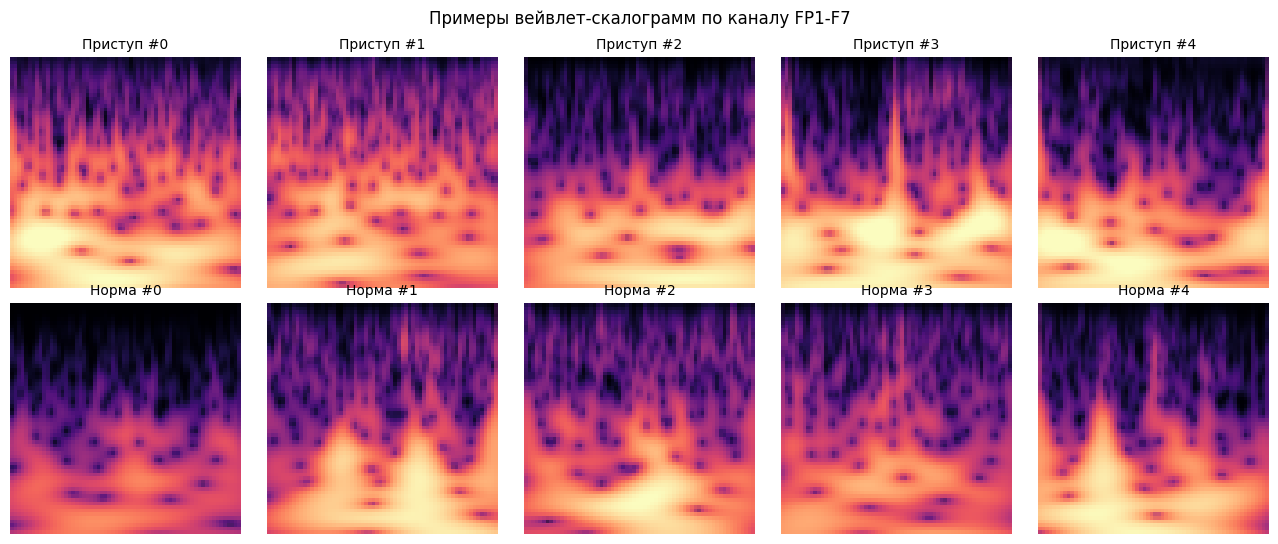

In [59]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for i in range(5):
    sz = Image.open(SEIZURE_DIR / f'sz_{i:03d}.png')
    nm = Image.open(NORMAL_DIR  / f'nm_{i:03d}.png')
    axes[0, i].imshow(sz)
    axes[0, i].set_title(f'Приступ #{i}', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(nm)
    axes[1, i].set_title(f'Норма #{i}',   fontsize=10)
    axes[1, i].axis('off')
plt.suptitle('Примеры вейвлет-скалограмм по каналу FP1-F7', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Подготовка датасета для CNN



In [ ]:
def load_images_from_dir(directory: Path, label: int):
    files = sorted(directory.glob('*.png'))
    X = np.stack([np.asarray(Image.open(f).convert('RGB')) for f in files])
    y = np.full(len(files), label, dtype=np.int32)
    return X, y

X_sz, y_sz = load_images_from_dir(SEIZURE_DIR, label=1)
X_nm, y_nm = load_images_from_dir(NORMAL_DIR,  label=0)

X = np.concatenate([X_sz, X_nm], axis=0)
y = np.concatenate([y_sz, y_nm], axis=0)
print(f'Полный датасет: X={X.shape}  y={y.shape}  (dtype: {X.dtype})')

X_tv, X_te, y_tv, y_te = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_tv, y_tv, test_size=0.20, stratify=y_tv, random_state=SEED
)
print(f'Train: {X_tr.shape},  Val: {X_va.shape},  Test: {X_te.shape}')
print(f'Баланс train: приступы = {int(y_tr.sum())}, норма = {int((1-y_tr).sum())}')

Полный датасет: X=(120, 64, 64, 3)  y=(120,)  (dtype: uint8)
Train: (76, 64, 64, 3),  Val: (20, 64, 64, 3),  Test: (24, 64, 64, 3)
Баланс train: приступы = 38, норма = 38


## 9. Архитектура свёрточной сети


In [75]:
def build_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape, name='scalogram'),
        layers.Rescaling(1.0 / 255.0),

        layers.Conv2D(16, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='sigmoid', name='p_seizure'),
    ], name='EEG_CNN')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )
    return model

model = build_cnn()
model.summary()

Model: "EEG_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_seizure (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 287,905 (1.10 MB)

 Trainable params: 287,905 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Обучение


In [76]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/50
5/5 - 1s - 251ms/step - accuracy: 0.5132 - loss: 0.7057 - val_accuracy: 0.8500 - val_loss: 0.6792
Epoch 2/50
5/5 - 0s - 14ms/step - accuracy: 0.4342 - loss: 0.7429 - val_accuracy: 0.5500 - val_loss: 0.6715
Epoch 3/50
5/5 - 0s - 13ms/step - accuracy: 0.5000 - loss: 0.6792 - val_accuracy: 0.5500 - val_loss: 0.6694
Epoch 4/50
5/5 - 0s - 14ms/step - accuracy: 0.6316 - loss: 0.6558 - val_accuracy: 0.7000 - val_loss: 0.6580
Epoch 5/50
5/5 - 0s - 14ms/step - accuracy: 0.5658 - loss: 0.6802 - val_accuracy: 0.8000 - val_loss: 0.6413
Epoch 6/50
5/5 - 0s - 14ms/step - accuracy: 0.6711 - loss: 0.6509 - val_accuracy: 0.7000 - val_loss: 0.6220
Epoch 7/50
5/5 - 0s - 14ms/step - accuracy: 0.6711 - loss: 0.6227 - val_accuracy: 0.8500 - val_loss: 0.5841
Epoch 8/50
5/5 - 0s - 14ms/step - accuracy: 0.6842 - loss: 0.5926 - val_accuracy: 0.8000 - val_loss: 0.5392
Epoch 9/50
5/5 - 0s - 14ms/step - accuracy: 0.6447 - loss: 0.6126 - val_accuracy: 0.9000 - val_loss: 0.5071
Epoch 10/50
5/5 - 0s - 13ms

### 10.1 Кривые обучения

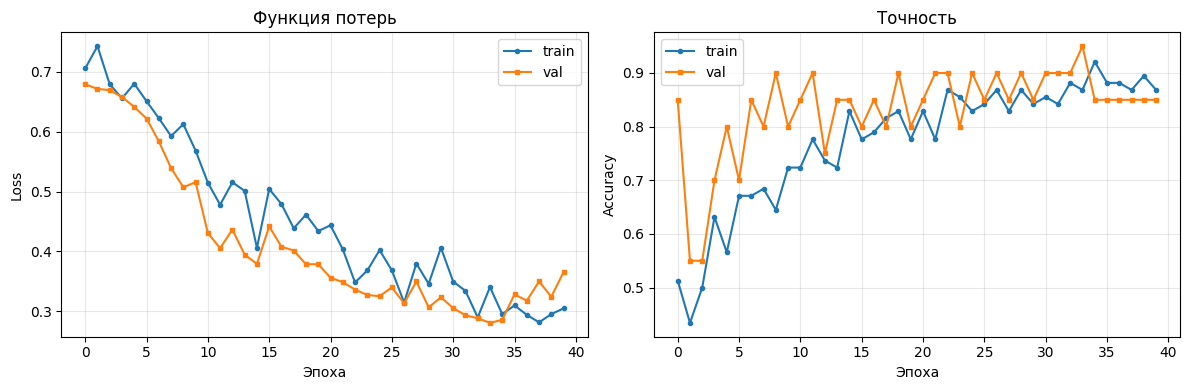

In [77]:
hist = history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist['loss'],     label='train', marker='o', ms=3)
axes[0].plot(hist['val_loss'], label='val',   marker='s', ms=3)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь'); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(hist['accuracy'],     label='train', marker='o', ms=3)
axes[1].plot(hist['val_accuracy'], label='val',   marker='s', ms=3)
axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность'); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Оценка на тестовой выборке


In [78]:
test_loss, test_acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Тестовая accuracy: {test_acc:.3f}')
print(f'Тестовый loss:     {test_loss:.3f}')

y_proba = model.predict(X_te, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)

print('\nClassification report:')
print(classification_report(y_te, y_pred, target_names=['норма', 'приступ'], digits=3))

Тестовая accuracy: 0.958
Тестовый loss:     0.173

Classification report:
              precision    recall  f1-score   support

       норма      0.923     1.000     0.960        12
     приступ      1.000     0.917     0.957        12

    accuracy                          0.958        24
   macro avg      0.962     0.958     0.958        24
weighted avg      0.962     0.958     0.958        24



### 11.1 Матрица ошибок

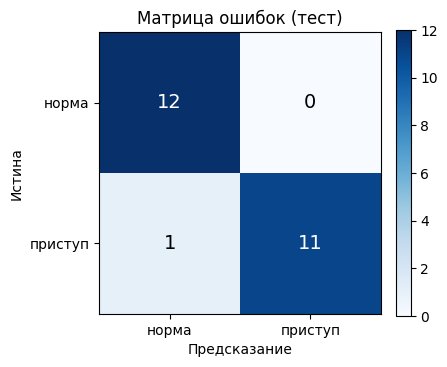

In [79]:
cm = confusion_matrix(y_te, y_pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['норма', 'приступ'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['норма', 'приступ'])
ax.set_xlabel('Предсказание'); ax.set_ylabel('Истина')
ax.set_title('Матрица ошибок (тест)')
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14, color=color)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 12. Сохранение модели и проверка работы


In [ ]:
model.save(MODEL_PATH)
size_mb = MODEL_PATH.stat().st_size / (1024 * 1024)
print(f'Модель сохранена: {MODEL_PATH}  ({size_mb:.2f} МБ)')

loaded = load_model(MODEL_PATH)
print('Модель успешно загружена обратно.')

same = all(
    np.allclose(a.numpy(), b.numpy())
    for a, b in zip(model.weights, loaded.weights)
)
print('Веса исходной и загруженной модели совпадают:', same)

Модель сохранена: eeg_cnn_model.keras  (3.35 МБ)
Модель успешно загружена обратно.
Веса исходной и загруженной модели совпадают: True


### 12.1 Демонстрация на нескольких тестовых примерах

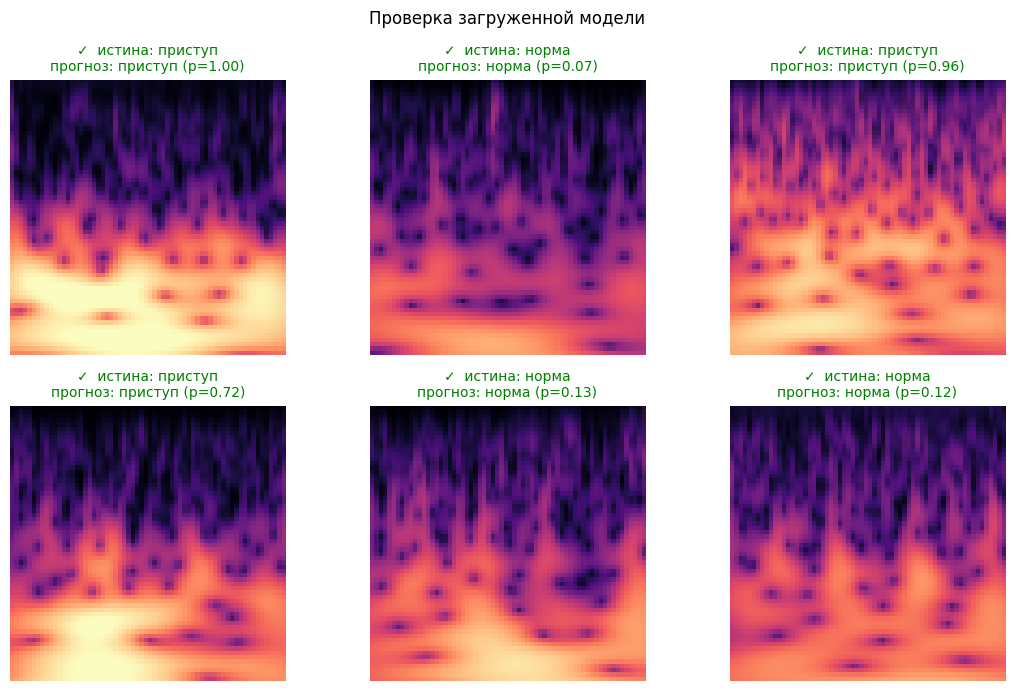

In [81]:
rng2 = np.random.default_rng(SEED + 1)
n_show = 6
idx_show = rng2.choice(len(X_te), size=n_show, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, i in zip(axes.flat, idx_show):
    img = X_te[i]
    true_lab = 'приступ' if y_te[i] == 1 else 'норма'
    p = float(loaded.predict(img[None], verbose=0).flatten()[0])
    pred_lab = 'приступ' if p >= 0.5 else 'норма'
    ok = '✓' if pred_lab == true_lab else '✗'
    color = 'green' if ok == '✓' else 'red'
    ax.imshow(img)
    ax.set_title(f'{ok}  истина: {true_lab}\nпрогноз: {pred_lab} (p={p:.2f})',
                 color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('Проверка загруженной модели', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Выводы

1. **Сформирована обучающая выборка** из CHB-MIT (chb08): по 60 окон каждого класса
2. Для каждого окна построено **вейвлет-изображение** 
3. Обучена компактная **CNN** 
   характерную энергетическую сигнатуру в средних частотах.
4. Модель сохранена в `eeg_cnn_model.keras` 

